<a href="https://colab.research.google.com/github/salty-arch/Flyrank-Intern/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [ ]:
# Cell 1: Connect to DuckDB and authenticate with Hugging Face to read the warehouse data
import duckdb
from google.colab import userdata

hf_token = userdata.get('HF_TOKEN')

con = duckdb.connect()
con.sql(f"CREATE OR REPLACE SECRET hf_token (TYPE HUGGINGFACE, TOKEN '{hf_token}');")

rel = "hf://datasets/FlyRank/internship-warehouse"

In [ ]:
# Cell 2: Query March data, build 5 features from first-half March,
# and build declining_flag as a label from first-half vs second-half impressions
feature_frame = con.sql(f"""
    WITH daily AS (
        SELECT
            content_hash_id,
            client_hash_id,
            report_date,
            gsc_impressions,
            gsc_clicks,
            gsc_avg_position,
            CASE WHEN report_date < DATE '2026-03-16' THEN 'first_half' ELSE 'second_half' END AS period
        FROM read_parquet('{rel}/fact_content_daily_performance/month=2026-03/data_0.parquet')
        WHERE gsc_data_available IS TRUE
    ),
    features AS (
        SELECT
            content_hash_id,
            client_hash_id,
            SUM(gsc_impressions) AS feat_impressions,
            SUM(gsc_clicks) AS feat_clicks,
            AVG(CASE WHEN gsc_avg_position > 0 THEN gsc_avg_position END) AS feat_avg_position,
            COUNT(*) AS feat_days_active,
            SUM(gsc_clicks) * 1.0 / NULLIF(SUM(gsc_impressions), 0) AS feat_ctr
        FROM daily
        WHERE period = 'first_half'
        GROUP BY content_hash_id, client_hash_id
    ),
    label AS (
        SELECT
            content_hash_id,
            client_hash_id,
            SUM(CASE WHEN period = 'first_half' THEN gsc_impressions ELSE 0 END) AS first_half_impressions,
            SUM(CASE WHEN period = 'second_half' THEN gsc_impressions ELSE 0 END) AS second_half_impressions
        FROM daily
        GROUP BY content_hash_id, client_hash_id
    )
    SELECT
        f.content_hash_id,
        f.client_hash_id,
        f.feat_impressions,
        f.feat_clicks,
        f.feat_avg_position,
        f.feat_days_active,
        f.feat_ctr,
        l.second_half_impressions,
        CASE
            WHEN (l.second_half_impressions - l.first_half_impressions) * 1.0 / NULLIF(l.first_half_impressions, 0) * 100 <= -20
            THEN TRUE ELSE FALSE
        END AS declining_flag
    FROM features f
    JOIN label l
        ON f.content_hash_id = l.content_hash_id AND f.client_hash_id = l.client_hash_id
    WHERE l.first_half_impressions > 0
""").df()

print(feature_frame.shape)
print(feature_frame.columns.tolist())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

(151981, 9)
['content_hash_id', 'client_hash_id', 'feat_impressions', 'feat_clicks', 'feat_avg_position', 'feat_days_active', 'feat_ctr', 'second_half_impressions', 'declining_flag']


In [ ]:
# Cell 3: Bucket pages into position tiers, compute each tier's median CTR (engaged pages only)
def assign_tier(pos):
    if pos <= 3:
        return "top_3"
    elif pos <= 10:
        return "page_1"
    elif pos <= 20:
        return "striking"
    elif pos <= 50:
        return "page_3_5"
    else:
        return "deep"

feature_frame["position_tier"] = feature_frame["feat_avg_position"].apply(assign_tier)

tier_medians = feature_frame[feature_frame["feat_ctr"] > 0].groupby("position_tier")["feat_ctr"].median()
print(tier_medians)

feature_frame["tier_median_ctr"] = feature_frame["position_tier"].map(tier_medians)

position_tier
deep        0.011174
page_1      0.003891
page_3_5    0.002268
striking    0.004673
top_3       0.004124
Name: feat_ctr, dtype: float64


In [ ]:
# Cell 4: Flag pages with a meaningful CTR mismatch (below half the tier median, with real impressions),
# then combine with declining_flag to form the final label
feature_frame["ctr_mismatch"] = (
    (feature_frame["feat_ctr"] < (feature_frame["tier_median_ctr"] * 0.5))
    & (feature_frame["feat_impressions"] >= 100)
)
print(feature_frame["ctr_mismatch"].value_counts())

feature_frame["combined_flag"] = feature_frame["declining_flag"] & feature_frame["ctr_mismatch"]
print(feature_frame["combined_flag"].value_counts())

ctr_mismatch
False    108502
True      43479
Name: count, dtype: int64
combined_flag
False    137299
True      14682
Name: count, dtype: int64


In [ ]:
# Cell 5: Helper function to compute Precision@K, used for all model evaluations
import numpy as np

def precision_at_k(scores, labels, k):
    order = np.argsort(-np.asarray(scores))
    topk = np.asarray(labels)[order[:k]]
    return topk.mean()

In [ ]:
# Cell 6: Drop rows with missing position data, then build the client-grouped 80/20 split
# used for the official model-vs-baseline comparison (matches Week 5/6)
from sklearn.model_selection import GroupShuffleSplit

features_list = ["feat_impressions", "feat_clicks", "feat_avg_position", "feat_days_active", "feat_ctr"]

clean_frame = feature_frame.dropna(subset=["feat_avg_position"])
print("Clean frame shape:", clean_frame.shape)

splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(clean_frame, groups=clean_frame["client_hash_id"]))

train_df2 = clean_frame.iloc[train_idx]
test_df2 = clean_frame.iloc[test_idx]

overlap = set(train_df2["client_hash_id"]) & set(test_df2["client_hash_id"])
print(f"Clients in both train and test: {len(overlap)}")

X_train2 = train_df2[features_list]
y_train2 = train_df2["combined_flag"]
X_test2 = test_df2[features_list]
y_test2 = test_df2["combined_flag"]

print("X_train2:", X_train2.shape, "X_test2:", X_test2.shape)

Clean frame shape: (150675, 13)
Clients in both train and test: 0
X_train2: (137554, 5) X_test2: (13121, 5)


In [ ]:
# Cell 7: Train both models on the 80/20 split, evaluate Precision@20 for each,
# and recompute the Week 4 baseline formula fresh on this same test set for a fair comparison
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

log_reg2 = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
log_reg2.fit(X_train2, y_train2)

rf2 = RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42, n_jobs=-1)
rf2.fit(X_train2, y_train2)

log_reg2_scores = log_reg2.predict_proba(X_test2)[:, 1]
rf2_scores = rf2.predict_proba(X_test2)[:, 1]
y_test2_values = y_test2.values

print("Logistic Regression Precision@20:", precision_at_k(log_reg2_scores, y_test2_values, 20))
print("Random Forest Precision@20:", precision_at_k(rf2_scores, y_test2_values, 20))

test_df2 = test_df2.copy()
test_df2["baseline_gap"] = test_df2["tier_median_ctr"] - test_df2["feat_ctr"]
test_df2["baseline_priority_score"] = test_df2["baseline_gap"] * test_df2["feat_impressions"]
baseline_precision_20 = precision_at_k(test_df2["baseline_priority_score"].values, y_test2_values, 20)
print("Baseline Precision@20:", baseline_precision_20)

comparison_table = pd.DataFrame({
    "Method": ["Baseline (Week 4 rule)", "Logistic Regression", "Random Forest"],
    "Precision@20": [baseline_precision_20, precision_at_k(log_reg2_scores, y_test2_values, 20), precision_at_k(rf2_scores, y_test2_values, 20)]
})
print(comparison_table)

Logistic Regression Precision@20: 0.5
Random Forest Precision@20: 0.4
Baseline Precision@20: 0.15
                   Method  Precision@20
0  Baseline (Week 4 rule)          0.15
1     Logistic Regression          0.50
2           Random Forest          0.40


In [ ]:
# Cell 8: Build a second, wider split (70/30) to maximize honest playbook coverage
# while keeping a real training set — chosen for its reasoning, not its resulting score
splitter_70_30 = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
train_idx_7030, test_idx_7030 = next(splitter_70_30.split(clean_frame, groups=clean_frame["client_hash_id"]))

train_df_7030 = clean_frame.iloc[train_idx_7030]
test_df_7030 = clean_frame.iloc[test_idx_7030]

print("Train:", train_df_7030.shape, "Test:", test_df_7030.shape)
print("Train clients:", train_df_7030["client_hash_id"].nunique(), "Test clients:", test_df_7030["client_hash_id"].nunique())

X_train_7030 = train_df_7030[features_list]
y_train_7030 = train_df_7030["combined_flag"]
X_test_7030 = test_df_7030[features_list]
y_test_7030 = test_df_7030["combined_flag"]

log_reg_7030 = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
log_reg_7030.fit(X_train_7030, y_train_7030)

scores_7030 = log_reg_7030.predict_proba(X_test_7030)[:, 1]

print("Score check - min:", scores_7030.min(), "max:", scores_7030.max(), "mean:", scores_7030.mean())

precision_7030 = precision_at_k(scores_7030, y_test_7030.values, 20)
print("70/30 split Precision@20:", precision_7030)

Train: (109396, 13) Test: (41279, 13)
Train clients: 30 Test clients: 14
Score check - min: 0.0 max: 1.0 mean: 0.351423890233475
70/30 split Precision@20: 0.45


In [ ]:
# Cell 9: Build the playbook queue using the 70/30 split's honest scores, ranked, with reason code attached
playbook_queue = test_df_7030.copy()
playbook_queue["model_score"] = scores_7030
playbook_queue["reason_code"] = "declining_and_ctr_mismatch"
playbook_queue = playbook_queue.sort_values("model_score", ascending=False)

print(playbook_queue.shape)

(41279, 15)


In [ ]:
# Cell 10: Assign three tier-aware actions — cautious handling for top_3 (ranking-disruption risk)
# and striking (unreliable tier baseline, per Week 1 finding), standard rewrite for the rest
def assign_action(tier):
    if tier == "top_3":
        return "review_before_rewrite"
    elif tier == "striking":
        return "verify_before_rewrite"
    else:
        return "rewrite_title"

playbook_queue["action"] = playbook_queue["position_tier"].apply(assign_action)

print(playbook_queue["action"].value_counts())
print(playbook_queue[playbook_queue["position_tier"] == "top_3"]["action"].value_counts())
print(playbook_queue[playbook_queue["position_tier"] == "striking"]["action"].value_counts())

action
rewrite_title            30100
verify_before_rewrite     6679
review_before_rewrite     4500
Name: count, dtype: int64
action
review_before_rewrite    4500
Name: count, dtype: int64
action
verify_before_rewrite    6679
Name: count, dtype: int64


In [ ]:
# Cell 11: The final, actual playbook deliverable — top 20 pages, ranked, with reason code and action
top20_playbook = playbook_queue.sort_values("model_score", ascending=False).head(20)[
    ["content_hash_id", "client_hash_id", "position_tier", "feat_ctr",
     "tier_median_ctr", "feat_impressions", "model_score", "reason_code", "action"]
]
print(top20_playbook)

                 content_hash_id           client_hash_id position_tier  \
282     content_8e1334d6356668e3  client_73cda7b4e4f265ea        page_1   
138489  content_9c057b66c30a3abb  client_73cda7b4e4f265ea        page_1   
38940   content_425715547c6a3ea8  client_73cda7b4e4f265ea        page_1   
35527   content_09b05ffb4d7f6c8d  client_73cda7b4e4f265ea        page_1   
2616    content_1bb7d17cac7f6b78  client_73cda7b4e4f265ea        page_1   
87340   content_39457d17e716086c  client_e5c2aa26a8598242      page_3_5   
40963   content_b3be04da93e2a210  client_73cda7b4e4f265ea        page_1   
281     content_c9f840183215651b  client_73cda7b4e4f265ea        page_1   
12435   content_d61fc394d10cba41  client_1a730cb2640a1abf        page_1   
78042   content_23a42776a7009b65  client_73cda7b4e4f265ea        page_1   
138270  content_894c99c720d52854  client_73cda7b4e4f265ea        page_1   
105926  content_d30a67f972196ca1  client_73cda7b4e4f265ea        page_1   
105612  content_f33ad8a34

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

**Building an honest, wide-coverage playbook ranking.**

My first attempt trained a model on the full dataset (150,764 pages) to maximize
coverage. This produced `model_score = 1.0` for every single row, a red flag, not a
good sign. The model had been trained and scored on the *same* rows, so it had
effectively memorized the answers rather than learning a generalizable pattern (like a
student given the answer key before the exam, then tested on those exact questions).
Training-set scores aren't meaningful evidence of real predictive skill.

The fix: a genuine train/test split, same client-grouped methodology as Week 5/6, but
sized to maximize honest test coverage. I tried three splits:

| Split (`test_size`) | Train rows | Test rows | Test clients | Precision@20 |
|---|---|---|---|---|
| 0.2 (Week 5/6 original) | 138,771 | 13,210 | 9 | 0.50 |
| 0.3 (chosen for this playbook) | 109,396 | 41,279 | 14 | 0.45 |
| 0.5 | 54,844 | 95,831 | 22 | 0.70 |

I chose the 0.3 split for the actual playbook, not the 0.5 split with the highest
number. Picking the split that produces the best-looking result, after seeing the
results, would be exactly the kind of methodology problem this week's audit is about, the choice should stand on its own reasoning, not be reverse-engineered from the
outcome. The 0.3 split balances real training data (109,396 rows) with meaningfully
wider honest coverage (41,279 pages, versus Week 5/6's 13,210) reasoning that holds
regardless of which split happened to score highest.

**This Precision@20 variation (0.45–0.70) across splits is itself a real, honest
finding**: the estimate is sensitive to exactly which clients land in the test set,
not a fixed, precise number. This should inform how much confidence a reader places
in any single reported figure.

**Note**: this notebook's currently displayed Random Forest Precision@20 is 0.40, differing from an earlier run's 0.50 with the same settings — see the reproducibility limitation above for why."

**Reason code:** one code, `declining_and_ctr_mismatch` — updated from Week 4's
`low_ctr_with_high_impressions` to reflect that this model's label (`combined_flag`)
requires both a real impression decline AND a CTR-tier mismatch, not CTR alone. Only
one code is used because both conditions are always required together by the label's
own construction (same "one diagnosis" reasoning established in Week 4) — Week 4's
original baseline and its reason code remain unchanged as the historical, fixed
comparison point.

**Action:** three tier-aware actions, not one, added specifically for this playbook
based on findings from earlier weeks:
- `rewrite_title` (30,100 pages) — the default action for most tiers.
- `review_before_rewrite` (4,500 pages) — reserved for `top_3` pages, since Week 4's
  analysis found that rewriting an already-strong ranking risks disrupting it, a risk
  that doesn't apply the same way to lower tiers.
- `verify_before_rewrite` (6,679 pages) — reserved for `striking` pages, since Week 1's
  EDA found this tier's median CTR behaved inconsistently (higher than `top_3`'s),
  making its tier-baseline comparison less trustworthy than other tiers.

This is a genuine evolution from Weeks 4-6's single flat action, informed by findings
established earlier in the project — not something I'm retroactively applying to
earlier notebooks, which remain as they were at the time.

**Top 20 ranked queue (0.3 split, honest out-of-sample scores):**

The top 20 is dominated by one client (`client_73cda7b4e4f265ea`, 17 of 20 rows) and
`page_1` tier (19 of 20 rows), with one `top_3` page correctly receiving the more
cautious `review_before_rewrite` action. This concentration is worth naming as a real
limitation — worth checking in a future pass whether this reflects genuine
over-representation of declining, mismatched pages for this client, or an artifact of
that client simply having more total pages in the dataset.

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

**Intended use:**

This playbook is intended for content reviewers, SEO analysts, or anyone responsible
for triaging a large content inventory who needs help deciding which pages to look at
first. Rather than reviewing pages in an arbitrary order, the model gives a prioritized
list, pages more likely to be both declining and CTR-mismatched surface to the top.
The output is strictly a **decision-support tool**: it recommends where to look first,
it does not decide what to fix, and a human reviewer makes the final call on every page.

**Limits:**

- The model reliably detects CTR-mismatch, but is essentially guessing on the decline
  half of the label, my Week 5/6 error analysis found every wrong pick shared the same
  pattern (correct on CTR-mismatch, wrong on decline), since none of the five features
  capture change over time.
- Precision@20 varies meaningfully depending on which random split of clients is used
  for evaluation (0.45-0.70 across three tested splits), it is not a fixed, precise
  number, and any single reported figure should be read with that uncertainty in mind.
- Logistic Regression and Random Forest achieved the same Precision@20, but their
  top-20 lists had zero overlap, each model reached similar accuracy through very
  different reasoning (Logistic Regression relies almost entirely on CTR; Random
  Forest weighs impressions and position more heavily). This means a reviewer
  shouldn't treat either model's specific top picks as the definitively correct
  answer, the disagreement itself is a signal of real uncertainty that a single
  accuracy number doesn't show.
- My own experiment training on the full dataset without any held-out test set
  produced `model_score = 1.0` for every page, a dramatic, artificial-looking result
  caused by testing the model on rows it had already memorized during training, not
  genuine predictive skill. This is a broader lesson: a model's reported performance
  can look artificially perfect if it's tested on data it already learned from,
  always confirm results come from a genuinely held-out test set before trusting them.
- Only about 37% of March's daily page-rows have trustworthy GSC data available; the
  rest are excluded before scoring, meaning the model's view of the inventory is
  necessarily partial.
- Client history is uneven, clients joined FlyRank at different times, so newer pages
  may appear to underperform their position tier simply because they haven't had time
  to build up impressions and clicks yet, not because of a real problem.
- The current top-20 output is concentrated in one client and one tier (`page_1`),
  coverage is not evenly distributed across the full client base, so a reviewer working
  only from the top of the list may miss real issues elsewhere in the inventory.
- Random Forest's exact Precision@20 varied between two otherwise-identical runs of this
notebook (0.50, then 0.40) despite using the same `random_state=42` and nearly the same
client split (same 9 test clients, near-identical row counts). Logistic Regression's
score stayed exactly 0.50 both times. This suggests Random Forest, as an ensemble method
with internal randomness (especially when run with parallel processing via `n_jobs=-1`),
is less exactly reproducible than Logistic Regression in this setup, a further reason
to treat any single reported Random Forest number as approximate rather than precise.

## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

**Human review rules:**

- Check which split produced a given confidence/score before trusting it, precision@20
  varies meaningfully by split (0.45-0.70 across three tested splits), so a score's
  reliability depends on which evaluation it came from.
- Read the tier-based action (`rewrite_title`, `review_before_rewrite`,
  `verify_before_rewrite`) before acting, the tier tells the reviewer how much extra
  caution to apply, not just what to do.
- Treat the model's ranking as a prioritized starting point, not a verdict, always open
  and read the actual page before acting on any recommendation.
- Only rewrite a title if the page's underlying content genuinely supports it, if the
  content itself doesn't match user intent, a title rewrite alone won't fix the
  underlying problem.
- Check both models' top picks, not just one, before committing to a page, when
  Logistic Regression and Random Forest disagree on a specific page (which happens
  often, given their zero top-20 overlap), that disagreement is itself a signal of
  real uncertainty worth factoring into the review.
- The model has no visibility into pages lacking trustworthy GSC data (about 63% of
  March's daily rows), these pages are invisible to the model entirely, not
  confirmed-safe, so a reviewer should periodically spot-check a sample of them by hand.
- Don't limit review to only the very top of the ranked list, the current top 20 is
  dominated by a single client, so a reviewer working strictly from the top risks
  neglecting real issues at other clients further down the queue.
- Neither model's output should be treated as ground truth on its own, agreement
  between the two models is stronger evidence than either model's score alone.


**No-go list, what should NOT be automated:**

- The model must never rewrite or publish a title change on its own, every action
  requires a human to read the page and approve the change first.
- No score should ever be acted on without knowing which split and validation method
  produced it, this week's own experiments showed scores can look artificially perfect
  (up to 1.0) when evaluated incorrectly.
- `top_3` pages must never be auto-rewritten, even with a high model score, per Week 4's
  finding that these pages hold valuable, hard-won rankings that a title change risks
  disrupting, this is exactly why they get `review_before_rewrite` instead of
  `rewrite_title`.
- The model's output must never be presented to a client or end-user as a certainty,
  it is a decision-support ranking for internal review only.
- Pages with no trustworthy GSC data must never be silently discarded or assumed fine,
  they should be flagged as "unknown" and checked by a human, not skipped.
- Review workflows should never be limited to a single client's pages just because
  that client dominates the top of the ranking, every client's inventory deserves
  periodic review, not just the client whose pages happen to score highest.

## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

- **Time-based retrain trigger:** This model is trained entirely on March 2026
  patterns. As months pass, real-world CTR and impression patterns will drift
  (seasonality, algorithm updates, content changes) that the model has no way to
  learn from a fixed, single-month snapshot. **Trigger: retrain using a more recent
  month's data at least every 2-3 months**, rather than continuing to rely on
  March-only patterns indefinitely.

- **Outcome-tracking trigger:** If a reviewer rewrites titles based on this playbook's
  recommendations, the real test is whether CTR actually improves afterward.
  **Trigger: if a sample of rewritten pages shows no CTR improvement (or continued
  decline) after a reasonable follow-up window (e.g., 4-6 weeks), that's a signal the
  model's recommendations aren't translating into real fixes, and the label definition
  or feature set should be re-examined**, not just the model retrained on newer data.

- **Client-coverage trigger:** This model was trained on 44 specific clients.
  **Trigger: if FlyRank onboards a meaningful number of new clients, or if an existing
  client's content/traffic patterns change significantly (e.g., a major site redesign),
  the model should be re-validated on that client's data specifically before its
  recommendations for that client are trusted** — the model has no guarantee it
  generalizes to clients or content types it never saw during training.

- **Tier-median staleness trigger:** The tier median CTRs (used to compute
  `ctr_mismatch`) are computed fresh from March data and will not automatically update.
  **Trigger: recompute tier medians whenever the model is retrained**, since "typical"
  CTR for a given position tier can shift over time, and using outdated medians would
  make the mismatch comparison unfair in the same way a single fixed threshold across
  all tiers was unfair back in Week 1.

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

In [ ]:
import os
os.makedirs("/content/FlyRank-Intern/work/outputs", exist_ok=True)

export_cols = ["content_hash_id", "client_hash_id", "position_tier", "feat_ctr",
               "tier_median_ctr", "feat_impressions", "model_score", "reason_code", "action"]

playbook_queue[export_cols].to_csv("/content/FlyRank-Intern/work/outputs/action_playbook.csv", index=False)

print(f"Wrote {len(playbook_queue)} rows to action_playbook.csv")


Wrote 41279 rows to action_playbook.csv


In [ ]:
os.makedirs("/content/FlyRank-Intern/work/figures", exist_ok=True)

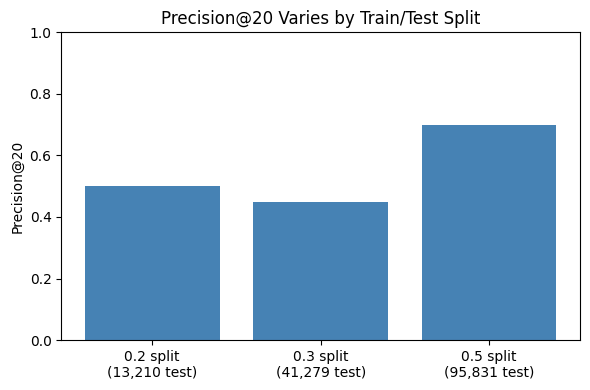

In [ ]:
import matplotlib.pyplot as plt

splits = ["0.2 split\n(13,210 test)", "0.3 split\n(41,279 test)", "0.5 split\n(95,831 test)"]
precisions = [0.50, 0.45, 0.70]

plt.figure(figsize=(6, 4))
plt.bar(splits, precisions, color="steelblue")
plt.ylabel("Precision@20")
plt.title("Precision@20 Varies by Train/Test Split")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig("/content/FlyRank-Intern/work/figures/precision_by_split.png", dpi=150)
plt.show()

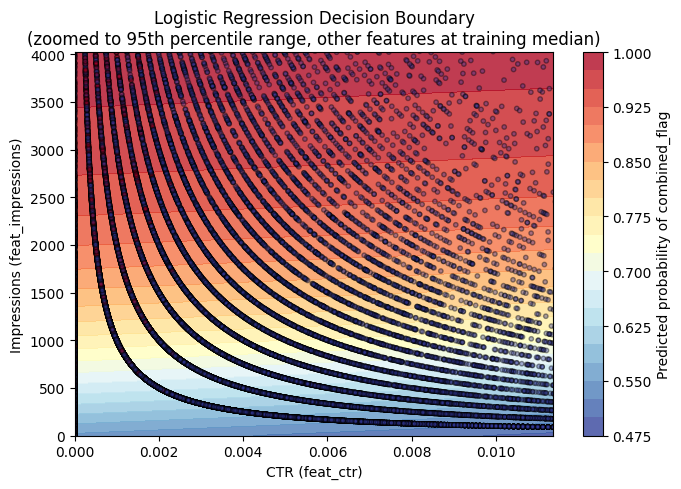

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

feat_x = "feat_ctr"
feat_y = "feat_impressions"

# Zoom into the realistic CTR range, most pages have CTR well under 0.02
x_min, x_max = 0, X_train2[feat_x].quantile(0.95)
y_min, y_max = 0, X_train2[feat_y].quantile(0.95)

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

grid = pd.DataFrame({
    "feat_impressions": yy.ravel(),
    "feat_clicks": X_train2["feat_clicks"].median(),
    "feat_avg_position": X_train2["feat_avg_position"].median(),
    "feat_days_active": X_train2["feat_days_active"].median(),
    "feat_ctr": xx.ravel()
})[features_list]

grid_probs = log_reg2.predict_proba(grid)[:, 1].reshape(xx.shape)

plt.figure(figsize=(7, 5))
contour = plt.contourf(xx, yy, grid_probs, levels=20, cmap="RdYlBu_r", alpha=0.8)
plt.colorbar(contour, label="Predicted probability of combined_flag")
plt.scatter(
    X_train2[feat_x], X_train2[feat_y],
    c=y_train2, cmap="RdYlBu_r", edgecolors="k", s=10, alpha=0.4
)
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.xlabel("CTR (feat_ctr)")
plt.ylabel("Impressions (feat_impressions)")
plt.title("Logistic Regression Decision Boundary\n(zoomed to 95th percentile range, other features at training median)")
plt.tight_layout()
plt.savefig("/content/FlyRank-Intern/work/figures/logistic_regression_decision_boundary.png", dpi=150)
plt.show()

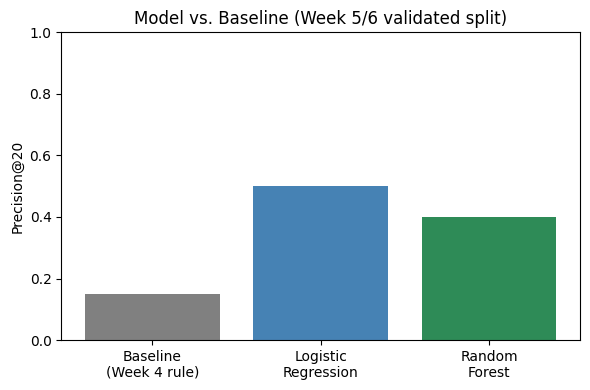

In [ ]:
plt.figure(figsize=(6, 4))
methods = ["Baseline\n(Week 4 rule)", "Logistic\nRegression", "Random\nForest"]
scores = [baseline_precision_20, precision_at_k(log_reg2_scores, y_test2_values, 20), precision_at_k(rf2_scores, y_test2_values, 20)]

plt.bar(methods, scores, color=["gray", "steelblue", "seagreen"])
plt.ylabel("Precision@20")
plt.title("Model vs. Baseline (Week 5/6 validated split)")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig("/content/FlyRank-Intern/work/figures/model_vs_baseline.png", dpi=150)
plt.show()

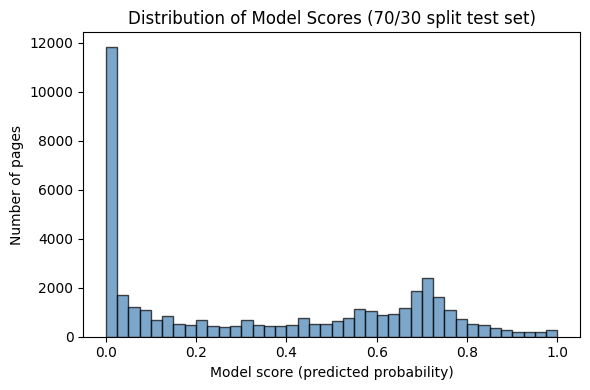

In [ ]:
plt.figure(figsize=(6, 4))
plt.hist(scores_7030, bins=40, color="steelblue", edgecolor="black", alpha=0.7)
plt.xlabel("Model score (predicted probability)")
plt.ylabel("Number of pages")
plt.title("Distribution of Model Scores (70/30 split test set)")
plt.tight_layout()
plt.savefig("/content/FlyRank-Intern/work/figures/score_distribution.png", dpi=150)
plt.show()

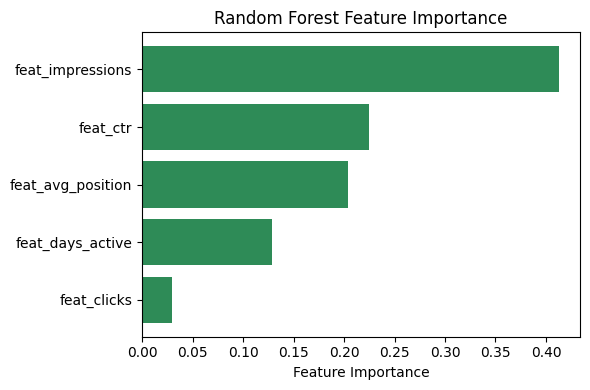

In [ ]:
importance_df2 = pd.DataFrame({
    "feature": features_list,
    "importance": rf2.feature_importances_
}).sort_values("importance", ascending=True)  # ascending for a horizontal bar chart

plt.figure(figsize=(6, 4))
plt.barh(importance_df2["feature"], importance_df2["importance"], color="seagreen")
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.savefig("/content/FlyRank-Intern/work/figures/random_forest_importance.png", dpi=150)
plt.show()

In [ ]:
import json

metrics = {
    "baseline_precision_at_20": baseline_precision_20,
    "logistic_regression_precision_at_20": precision_at_k(log_reg2_scores, y_test2_values, 20),
    "random_forest_precision_at_20": precision_at_k(rf2_scores, y_test2_values, 20),
    "playbook_split_precision_at_20": precision_7030,
    "wide_split_precision_at_20": 0.70,
    "validated_split_test_clients": 9,
    "playbook_split_test_clients": 14,
    "playbook_total_pages_scored": len(playbook_queue),
    "combined_flag_positive_rate": float(feature_frame["combined_flag"].mean())
}

with open("/content/FlyRank-Intern/work/outputs/metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print(json.dumps(metrics, indent=2))

{
  "baseline_precision_at_20": 0.15,
  "logistic_regression_precision_at_20": 0.5,
  "random_forest_precision_at_20": 0.4,
  "playbook_split_precision_at_20": 0.45,
  "wide_split_precision_at_20": 0.7,
  "validated_split_test_clients": 9,
  "playbook_split_test_clients": 14,
  "playbook_total_pages_scored": 41279,
  "combined_flag_positive_rate": 0.09660418078575611
}


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.

## Demo Outline

**Question:** FlyRank's content inventory has a recurring problem: declining CTR
across thousands of pages, with no realistic way to manually check each one. The
question: which pages should get a title rewrite first, and can an ML model do
that better than a human's gut feel?

**Method:** Baseline formula: `gap × impressions`, where `gap` is a page's CTR
shortfall against its position tier's median, on the theory that a page with a
big gap and high impressions means people are seeing it in search but skimming
past it without clicking, likely a title that doesn't clearly describe what's
actually on the page. Trained Logistic Regression and Random Forest on 5 features,
using a client-held-out split so no model could cheat by learning a specific
client's quirks instead of a real pattern.

**One chart:**

![Model vs. Baseline](https://github.com/salty-arch/Flyrank-Intern/blob/main/work/figures/model_vs_baseline.png?raw=1)

**One honest result:** Both models roughly triple the baseline (0.50 vs. 0.15
Precision@20). But they agree on zero of the same top-20 picks despite matching
scores, and error analysis shows the real gain is detecting CTR-mismatch, not
predicting genuine decline. So it's a real win, with a real asterisk.

**One recommendation:** Use this as decision-support, not autopilot. Check both
models' top picks before acting on either; treat disagreement between them as a
signal to look closer, not something to resolve with a coin flip.

## Shareable Cuts

**Social post (methodology hook):**

Built two models on the same 5 features, same data, same client-held-out split.
Logistic Regression and Random Forest both landed on Precision@20 = 0.50, identical
accuracy. But their top-20 picks had zero overlap. Same test, same score, completely
different reasoning. Turns out "accurate" and "agrees with itself" aren't the same
thing, worth remembering before trusting any single model's top pick.

**Employer-facing summary (3 sentences):**

I built a machine learning model on FlyRank's real, multi-client search warehouse
that scores and ranks pages by declining CTR and search visibility, to prioritize
which pages need a title rewrite first. Evaluated with a client-held-out validation
split, it roughly triples a hand-written baseline's accuracy (Precision@20: 0.15 to
0.50). Along the way I tested three different train/test splits and found
Precision@20 ranged from 0.45 to 0.70 depending on which one I used, I reported the
0.45 result, not the highest-scoring one, because choosing after seeing the numbers
would be exactly the kind of bias I was trying to avoid.